In [1]:
import pandas as pd
import seaborn as sns
import json
import pandas as pl
import glob
import codecs
import ntpath
import os
import datetime
from conversions import get_file_without_path
import numpy as np
import time

import matplotlib.pylab as plt

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.max_colwidth  = None

/Users/arias/opt/anaconda3/envs/stim39/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Check missing data

In [20]:
all_sentences_df = pd.read_csv("participant_data/all_sentences_df.csv")


In [21]:
print("Total number of real participant interactions : " + str(len(all_data_df.groupby(["sid", "dyad", "user_id"]).mean(numeric_only=True))))

print("Total number of transcription interactions : " + str(len(all_sentences_df.groupby(["sid", "dyad", "participant"]).mean(numeric_only=True))))



Total number of real participant interactions : 201
Total number of transcription interactions : 174


In [22]:
#check transcriptions files in folders:
from_transcriptions = pd.DataFrame()
for file in glob.glob('data/transcription/prolific/*.txt'):
    sid = file.split("/")[-1].split("-")[6]
    dyad = file.split("/")[-1].split("-")[9]
    participant = file.split("/")[-1].split("-")[11]
    rec_nb = file.split("/")[-1].split("-")[13]

    df_aux = pd.DataFrame()
    df_aux["sid"] = [sid]
    df_aux["dyad"] = [dyad]
    df_aux["participant"] = [participant]
    df_aux["rec_nb "] = [rec_nb]

    from_transcriptions = pd.concat([from_transcriptions, df_aux])

# Predicting participants' ratings with chat GPT


In [24]:
all_data_df = pl.read_csv("../data/behavior/all_data_df.csv")
all_data_df.head()

,Unnamed: 0,index,sid,dyad,user_id,other_id,participant_condition,other_condition,question_content,measure
0,0,0,mk:prolific_participant_real_2:1,p1p5,mk:prolific_participant_real_2:1p1,mk:prolific_participant_real_2:1p5,U,U,liked,4.0
1,1,1,mk:prolific_participant_real_2:1,p1p5,mk:prolific_participant_real_2:1p1,mk:prolific_participant_real_2:1p5,U,U,other_liked,4.0
2,2,2,mk:prolific_participant_real_2:1,p1p5,mk:prolific_participant_real_2:1p1,mk:prolific_participant_real_2:1p5,U,U,conversation_quality,5.0
3,3,3,mk:prolific_participant_real_2:1,p1p5,mk:prolific_participant_real_2:1p1,mk:prolific_participant_real_2:1p5,U,U,video_conf_quality,7.0
4,4,4,mk:prolific_participant_real_2:1,p1p5,mk:prolific_participant_real_2:1p5,mk:prolific_participant_real_2:1p1,U,U,liked,7.0


In [ ]:
# Using azure credentials
from openai import AzureOpenAI
import os

endpoint = "https://eddaopenai.cognitiveservices.azure.com/openai/deployments/Edda4o/chat/completions?api-version=2025-01-01-preview"
model_name = "gpt-4o"
deployment = "Edda4o"
OPENAI_API_KEY = "enter_your_key"

api_version = "2024-02-01"

client = AzureOpenAI(
    api_version=api_version,
    azure_endpoint=endpoint,
    api_key=OPENAI_API_KEY,
)

import json
import pandas as pd

def get_analysis_azure(prompt, system_prompt):
    response = client.chat.completions.create(
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": prompt}
        ],
        temperature=0.0,
        top_p=1.0,
        seed=50,
        response_format={ "type": "json_object" }, # Forces Azure to return valid JSON
        model=deployment
    )
    
    # Get the string response
    raw_response = response.choices[0].message.content
    
    # Convert the JSON string into a Python dictionary
    try:
        parsed_json = json.loads(raw_response)
        
        # Convert the dictionary into a Pandas DataFrame!
        # This gives you the exact same tabular data you wanted originally
        df_result = pd.DataFrame(parsed_json["ratings"])
        
        # Convert it to a CSV string to save it to your file
        return df_result.to_csv(index=False)
        
    except Exception as e:
        print(f"Failed to parse JSON: {e}")
        return raw_response

if __name__ == "__main__":
    print("Sending request to Azure OpenAI...")
    try:
        # We just need to add the word "JSON" to the prompt so the API lets it through
        result = get_analysis_azure(
            prompt="Write a one-sentence greeting and output it in JSON format.", 
            system_prompt="You are a helpful AI assistant."
        )
        print("\n✅ Success! Response:")
        print(result)
    except Exception as e:
        print(f"\n❌ Request failed: {e}")

In [26]:
all_data_df = pd.read_csv("participant_data/all_sentences_df.csv")

In [17]:
system_prompt = """You are an expert behavioral psychologist and data analyst specializing in human interaction. Your primary task is to read text transcripts of 4-minute video conversations between strangers and objectively evaluate and rate the interaction from the perspective of an expert observer, assessing each participant's actual psychological experience.

CRITICAL INSTRUCTIONS:
1. Look beyond superficial politeness. Evaluate genuine psychological engagement, mutual validation, and conversational flow.
2. Evaluate how each participant actually felt and behaved based on objective psychological markers, writing your explanations from the analytical perspective of a researcher.
3. You must output YOUR ENTIRE RESPONSE as a single, valid JSON object. Do not include markdown formatting like ```json or any conversational filler outside of the JSON."""

In [18]:
instructions = """I have a transcription of an interaction between two participants in a psychological experiment. Two strangers interacted via video conference for 4 minutes to see if they could become friends. 

Please read the conversation below and objectively rate the following 5 dimensions for EACH participant. Use a scale from 1 to 7, where 1 means 'not at all' and 7 means 'a lot'.

THE DIMENSIONS:
Q1: To what extent did the other person signal they had a good time talking to this participant? (Code: other_liked_me)
Q2: To what extent did this participant actually have a good time talking with the other person? (Code: liked)
Q3: To what extent was the conversation pleasant and interesting for this participant? (Code: conversation_quality)
Q4: Was the quality of the videoconference call good for this participant? (Code: video_conference_quality)
Q5: How was the quality of the transcription? (Code: transcription_quality)

EXPERT PSYCHOLOGY RUBRIC (CRITICAL):
- DEEP REFLECTION ON SOCIAL DYNAMICS: You must reflect deeply on the exact meaning of each dimension and how conversational mechanics (e.g., who spoke the most, who asked questions, who was just listening) impact them differently:
    * 'liked' (Internal State): Did this specific person actually have fun? If they were stuck acting as a captive audience to a monologue, or had to "pull teeth" to get answers, their 'liked' score should be low, regardless of how the overall chat looked.
    * 'other_liked_me' (Meta-Perception Signals): What signals did the OTHER person send? If P2 talked eagerly and laughed a lot, you must rate 'other_liked_me' highly for P1, EVEN IF P1's own 'liked' score is very low.
    * 'conversation_quality' (Objective Flow): Was the topic interesting and the flow smooth? A conversation can be highly pleasant and interesting (score 4-5) even if a participant didn't feel a deep, personal spark of friendship ('liked' = 2-3).
- THE "2 IS AVERAGE" HIGH-RESOLUTION SCALE: To capture human nuance, you must shift your baseline. A perfectly fine, polite conversation is a 2. Use this exact scale:
    * Score 1 (Poor/Disconnected): Awkward, forced, pulling teeth, one-word answers, or dead air.
    * Score 2 (Average/Superficial): THIS IS THE DEFAULT BASELINE. Polite small talk (hometown, "nice to meet you"). They maintain the chat but show no real spark or deep curiosity. Just going through the motions.
    * Score 3 (Above Average): Noticeably better than standard small talk. Active follow-up questions, some genuine curiosity, and smooth transitions.
    * Score 4 (Good/Warm): Natural flow, very comfortable, shared light laughter, and mutual participation.
    * Score 5 (Engaged): Frequent validation ("wow!", "cool!"), shared laughter, and mutual hype over a topic.
    * Score 6 (Excellent): Easy rapport, mutual interests, vibrant interaction.
    * Score 7 (Great): Great camaraderie, fun and deep bond, high level of connection.
- RADICAL DIVERGENCE (ASYMMETRY): Because of the social dynamics mentioned above, P1 and P2 will frequently have wildly different experiences. Actively look for lopsided interactions and rate the participants completely independently.
- Video Quality vs. Initial Awkwardness: Humans completely forgive initial tech setup. Even if there are 20 lines of "I can't hear you" at the beginning, if the call stabilizes and they converse normally, rate the video_conference_quality HIGH (5-7). Only rate it poorly (1-3) if the tech fails repeatedly in the MIDDLE of the conversation.
- Ignoring Transcript Glitches: Auto-generated transcripts often contain duplicated blocks of text, overlapping timestamps, and messy formatting. Do NOT penalize the 'liked' or 'conversation_quality' scores because of this. Only judge the underlying human interaction.

STRICT JSON SCHEMA REQUIREMENT (CRITICAL):
You MUST output a single valid JSON object. 
The root object must contain exactly one key: "ratings".
The "ratings" key must contain a list of exactly 10 objects.
EVERY object in the list MUST use these EXACT four keys (do not invent synonyms like 'score', 'value', or 'question'):
1. "participant_id" (String)
2. "question_code" (String - exactly as written in the questions list above)
3. "rating" (Integer from 1 to 7)
4. "comment" (String)

Example of the ONLY acceptable format (Note the deep reflection on social dynamics!):
{
  "ratings": [
    {
      "participant_id": "p1",
      "question_code": "liked",
      "rating": 2,
      "comment": "P1 maintained the conversation politely but had to do all the work asking questions, resulting in an objectively average/superficial experience."
    },
    {
      "participant_id": "p1",
      "question_code": "other_liked_me",
      "rating": 4,
      "comment": "Even though P1 was bored, P2 was happily answering all of P1's questions, sending clear signals that P2 had a warm, good time."
    }
  ]
}

Here is the transcription data to analyze:
"""

In [19]:
#check data
df_analysis = all_data_df
df_analysis = df_analysis.set_index(["sid", "dyad", "manipulated", "participant", "sentence_nb" ]).sort_index()[["start", "stop", "sentence"]].reset_index()
df_analysis.head()


,sid,dyad,manipulated,participant,sentence_nb,start,stop,sentence
0,mkprolific_participant_real_21,p1p5,dry,p1,1,0:00:24.160000,0:00:38.750000,Can you hear me? Yeah.
1,mkprolific_participant_real_21,p1p5,dry,p1,3,0:00:30.050000,0:00:38.750000,Hi.
2,mkprolific_participant_real_21,p1p5,dry,p1,5,0:00:31.240000,0:00:38.750000,Hi. Yeah.
3,mkprolific_participant_real_21,p1p5,dry,p1,7,0:00:35.450000,0:00:38.750000,"Does seem to be working. Yeah. Sorry, I'm just throwing out my headset."
4,mkprolific_participant_real_21,p1p5,dry,p1,9,0:00:38.310000,0:01:11.820000,Yeah.


In [20]:
# Analyse missing transcriptions
df_analysis = all_data_df
df_analysis = df_analysis.set_index(["sid", "dyad", "manipulated", "participant", "sentence_nb" ]).sort_index()[["start" , "stop", "sentence"]].reset_index()

analysis_folder = "data/predictions/gpt-4o_4/"

for (sid, dyad, manipulated), df in df_analysis.groupby(["sid", "dyad", "manipulated"]):
    analysis_file = analysis_folder + sid+"_"+ dyad+ "_" + manipulated + ".csv"
    if os.path.isfile(analysis_file):
        print("File exists : Skipping")
        continue
    
    print("#Starting analysis : " + sid + dyad +"------")
    
    #Export dyad
    df_aux = df.sort_values("sentence_nb").copy()
    df_aux = df_aux[["participant", "start" , "stop", "sentence"]]
    df_aux.to_csv("dyad.csv")

    if len(df_aux) == 0:
        print(sid +" " + dyad + " : Is empty, continuing")
        continue

    if len(df_aux.groupby(["participant"]).mean(numeric_only=True).reset_index()) != 2:
        print(sid +" " + dyad + " : has not sentences from two participants continuing")
        continue

    if len(df_aux) < 10: # minimum number of sentences in a conversation
        print(sid +" " + dyad + " : Is too short!! Continuing")
        continue

    
    #import dyad
    with open('dyad.csv', 'r') as file:
        data = file.read()
    
    #prepare prompt
    prompt = instructions + data
    
    result = get_analysis_azure(prompt= prompt, system_prompt=system_prompt)
    
    with codecs.open(analysis_file, "w", "utf-8-sig") as temp:
        temp.write(result)
    
    print(result)

    time.sleep(1)
    


#Starting analysis : mkprolific_participant_real_21p1p5------
participant_id,question_code,rating,comment
p1,other_liked_me,4,"P5 consistently validated P1 (e.g., 'Really?', 'Okay.', 'I do very much like it.', 'Correct. Okay.', 'Yeah, same.'), matched P1’s topics (Romanian background, London), and closed warmly. These are clear signals of a good, if not highly animated, experience with P1."
p1,liked,3,"P1 seemed mildly engaged: they initiated small talk ('where are you from'), shared a personal 'fun fact' about their ancestry, and commented on London’s cost of living. However, the long early confusion ('No. No. No...' while waiting for instructions) and lack of deeper follow-up suggest an above-average but not strongly enjoyable interaction."
p1,conversation_quality,3,"After a prolonged, confusing start with repeated 'No' and waiting for instructions, the conversation shifted into smoother small talk about origin, ancestry, and living in London. There was some genuine connection (share

## Import chat gpt data

In [27]:
#Prepare for merge with behavior data set
all_data_df = pl.read_csv("../data/behavior/all_data_df.csv")
all_data_df["sid"] = [x.replace(":","") for x in all_data_df["sid"].values]
all_data_df["user_id"] = [x.replace(":","") for x in all_data_df["user_id"].values]
all_data_df["other_id"] = [x.replace(":","") for x in all_data_df["other_id"].values]
print("nb participants : " + str(len(all_data_df.groupby(["sid", "user_id"]).mean(numeric_only=True))))

nb participants : 58


In [28]:
gpt_df = pd.DataFrame()

for file in glob.glob("data/predictions/gpt-4o_4.*/*.csv"):
    with open(file) as f: 
        s = f.read()
        if len(s)<10:
            continue
    print (file)
    aux_df = pd.read_csv(file, usecols=range(4), lineterminator='\n')
    aux_df.columns = [x.replace( " ", "") for x in aux_df.columns]
    dyad = file.split("_")[-2][0:4]
    aux  = file.split("/")[-1].split("_")
    sid = aux[0]+ "_" + aux[1]+ "_" + aux[2]+ "_" + aux[3]
    manipulated  = file.split("/")[-1][-7:-4]
    aux_df["dyad"] = [dyad for i in range(len(aux_df))]
    aux_df["sid"]  = [sid for i in range(len(aux_df))]
    aux_df["manipulated"]  = [manipulated for i in range(len(aux_df))]
    gpt_df = pd.concat([gpt_df, aux_df])

data/predictions/gpt-4o_4.2/mkreal_meeting_experiment_prolific5_p4p6_wet.csv
data/predictions/gpt-4o_4.2/mkreal_meeting_experiment_prolific2_p4p6_wet.csv
data/predictions/gpt-4o_4.2/mkprolific_participant_real_32_p4p8_dry.csv
data/predictions/gpt-4o_4.2/mkreal_meeting_experiment_prolific4_p1p7_dry.csv
data/predictions/gpt-4o_4.2/mkreal_meeting_experiment_prolific6_p4p7_dry.csv
data/predictions/gpt-4o_4.2/mkprolific_participant_real_32_p2p5_wet.csv
data/predictions/gpt-4o_4.2/mkprolific_participant_real_21_p2p8_dry.csv
data/predictions/gpt-4o_4.2/mkreal_meeting_experiment_prolific6_p3p5_dry.csv
data/predictions/gpt-4o_4.2/mkprolific_participant_real_22_p4p8_wet.csv
data/predictions/gpt-4o_4.2/mkreal_meeting_experiment_prolific4_p3p5_wet.csv
data/predictions/gpt-4o_4.2/mkprolific_participant_real_31_p4p5_dry.csv
data/predictions/gpt-4o_4.2/mkreal_meeting_experiment_prolific4_p4p7_wet.csv
data/predictions/gpt-4o_4.2/mkreal_meeting_experiment_prolific6_p1p7_wet.csv
data/predictions/gpt-4o_

In [29]:
print("nb of participants : " + str(len(gpt_df.groupby(["sid", "participant_id"]).mean(numeric_only=True))))

nb of participants : 58


In [30]:
#change transcription to column
group_cols = ['participant_id', 'dyad', 'sid', 'manipulated']
transcription_df = gpt_df[gpt_df['question_code'] == 'transcription_quality'][group_cols + ['rating']]
transcription_df = transcription_df.rename(columns={'rating': 'transcription_quality'})
gpt_df = gpt_df.merge(transcription_df, on=group_cols, how='left')

In [31]:
gpt_df.rename({"participant_id" : "user_id"}   , axis=1, inplace = True)
gpt_df.rename({'rating'         : "gpt_rating"} , axis=1, inplace = True)
gpt_df.rename({'question_code'       : "question_content"} , axis=1, inplace = True)

gpt_df["user_id"] = gpt_df["sid"] + [str(x) for x in gpt_df["user_id"].values]

gpt_df["question_content"] = [x.replace("other_liked_me", "other_liked") for x in gpt_df["question_content"].values]
gpt_df["question_content"] = [x.replace("video_conference_quality", "video_conf_quality") for x in gpt_df["question_content"].values]

gpt_df = gpt_df[["sid", "dyad", "user_id", "manipulated", "question_content", "gpt_rating", "comment", "transcription_quality"]]

print("nb participants : " + str(len(gpt_df.groupby(["sid", "user_id"]).mean(numeric_only=True))))


nb participants : 58


In [32]:
#Missing sessions or users?
missing_sessions = set(all_data_df['sid']) - set(gpt_df['sid'])
missing_sessions_list = list(missing_sessions)
print("missing sessions : " + str(len(missing_sessions)))


missing_sessions = set(all_data_df['user_id']) - set(gpt_df['user_id'])
missing_sessions_list = list(missing_sessions)
missing_sessions
print("missing users : " + str(len(missing_sessions)))

missing sessions : 0
missing users : 0


In [33]:
gpt_df = all_data_df.merge(gpt_df, on=["sid", "dyad", "user_id" , "question_content"], how="inner")
print("nb participants : " + str(len(gpt_df.groupby(["sid", "user_id"]).mean(numeric_only=True))))

nb participants : 58


In [34]:
df_analysis = gpt_df.groupby(["sid", "user_id", "other_id", "participant_condition", "other_condition", "question_content"]).mean(numeric_only=True).reset_index()
print("Number of participants : " + str(len(np.unique(df_analysis["user_id"]))))
df_analysis.to_csv("data/semantics_for_glmm.csv")

Number of participants : 58


In [35]:
gpt_df.to_csv("data/behavior_and_gpt4o_4.csv")

## Analysis

In [36]:
#Counting wrong interactions
gpt_df = pd.read_csv("data/behavior_and_gpt4o_4.csv")

print("nb participants before : " + str(len(gpt_df.groupby(["sid", "user_id"]).mean(numeric_only=True))))

gpt_df = gpt_df.loc[gpt_df["transcription_quality"] > 1]

print("nb participants after " + str(len(gpt_df.groupby("user_id").mean(numeric_only=True))))

len(gpt_df.groupby(["user_id", "dyad", "sid", "manipulated"]).mean(numeric_only=True))

nb participants before : 58
nb participants after 58


345

In [37]:
np.unique(gpt_df["question_content"])

array(['conversation_quality', 'liked', 'other_liked',
       'video_conf_quality'], dtype=object)

In [38]:
df_aux = df_analysis.loc[df_analysis["question_content"] == "liked"]
df_aux = df_aux.loc[df_aux["gpt_rating"] == 6]

np.unique(df_aux["user_id"].values)

array(['mkreal_meeting_experiment_prolific2p2'], dtype=object)

In [39]:
# Export transcriptions and analysis to a file for manual inspection (do this only if needed)
df_analysis = pd.read_csv("participant_data/all_sentences_df.csv")

# Assuming you already have a DataFrame named 'df'

# Open a file in write mode (added encoding="utf-8" to prevent emoji/special character crashes)
with open("analysis_results.txt", "w", encoding="utf-8") as f:
    for ind, df in df_analysis.groupby(["dyad", "sid"]):
        # 1. Write your custom header
        f.write(f"\n--------------- new ANALYSIS --------- : Data - {ind}\n")

        # Get the GPT ratings
        df_aux = gpt_df.loc[(gpt_df["dyad"] == ind[0]) & (gpt_df["sid"] == ind[1])]
        df_aux = df_aux[["user_id", "other_id", "question_content", "measure", "gpt_rating"]]
        
        # Write the ratings (added justify='left' so it doesn't float around)
        f.write("1. Comparison of GPT and Real Ratings\n")
        f.write(df_aux.to_string(index=False, justify='left') + "\n\n")
        
        # 2. Write the transcription line by line for natural reading
        f.write("2. Transcription\n")
        
        # Zip is highly efficient and skips the awful Pandas spacing
        for participant, sentence in zip(df["participant"], df["sentence"]):
            # This formats it cleanly like a script: "p1: Can you hear me?"
            f.write(f"{participant}: {sentence}\n")
        
        # 3. Add extra spacing between groups for readability
        f.write("\n" + "-"*40 + "\n")

print("Analysis successfully exported to analysis_results.txt")

Analysis successfully exported to analysis_results.txt


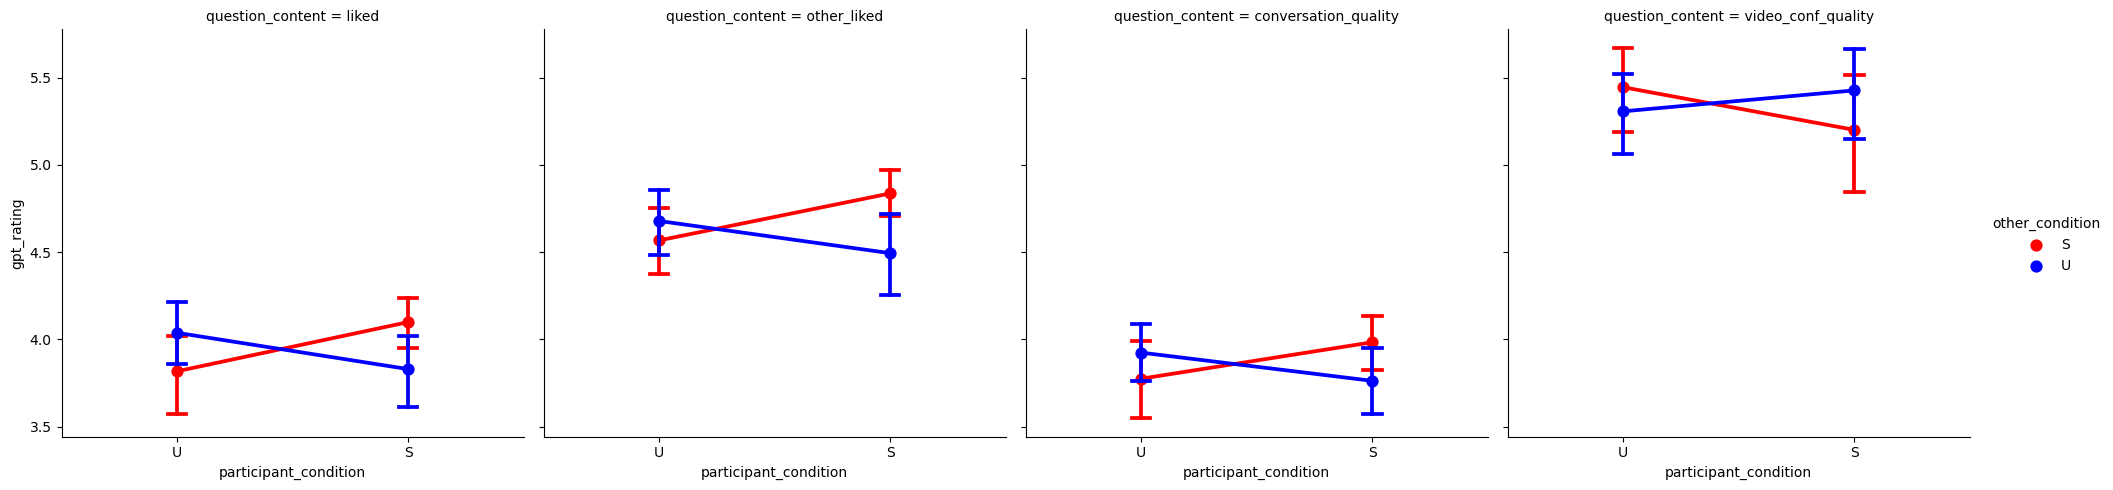

In [40]:
#Behavioral effect

df_analysis = gpt_df.groupby(["user_id", "other_id", "participant_condition", "other_condition", "question_content"]).mean(numeric_only=True).reset_index()

sns.catplot(x="participant_condition"
            , y="gpt_rating"
            , hue="other_condition"
            , col="question_content"
            , data=df_analysis
            , kind="point"
            , capsize=0.08
            , col_order= ["liked", "other_liked", "conversation_quality", "video_conf_quality"]
            , hue_order= ["S", "U"]
            , palette= ["red", "blue"]
           )

Number of participants : 58


/Users/arias/opt/anaconda3/envs/stim39/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/arias/opt/anaconda3/envs/stim39/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/arias/opt/anaconda3/envs/stim39/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/arias/opt/anaconda3/envs/stim39/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option i

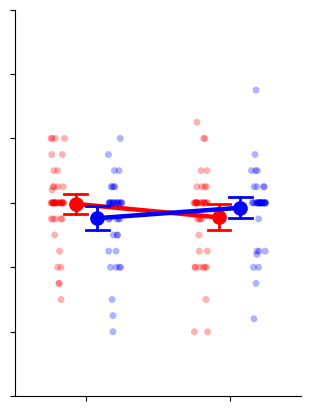

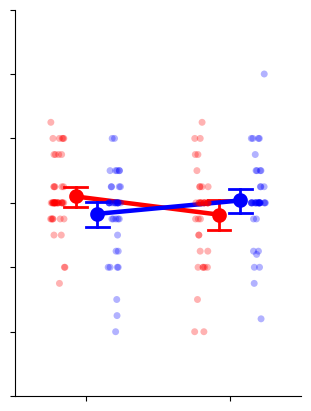

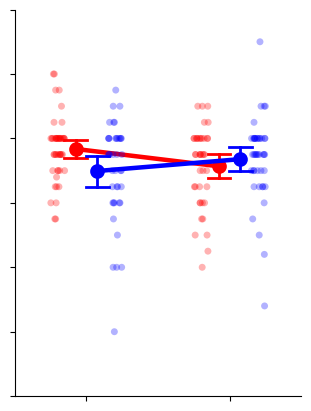

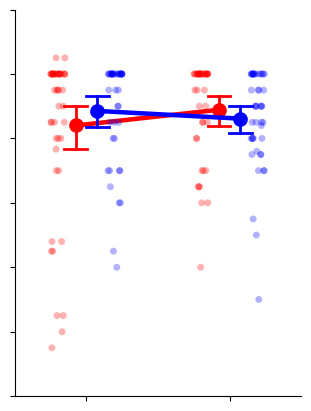

In [41]:
df_analysis = gpt_df.groupby(["sid", "user_id", "participant_condition", "other_condition", "question_content"]).mean(numeric_only=True).reset_index()
print("Number of participants : " + str(len(np.unique(df_analysis["user_id"]))))

for question_content in np.unique(df_analysis["question_content"]):
    df_analysis = gpt_df.groupby(["sid", "user_id", "participant_condition", "other_condition", "question_content"]).mean(numeric_only=True).reset_index()
    df_analysis = df_analysis.loc[df_analysis["question_content"] == question_content]
    
    g = sns.catplot( x="participant_condition", y="gpt_rating", units="user_id"
                        , height=4.6
                        , aspect=0.8
                        , data=df_analysis
                        , kind="point"
                        , capsize=.16
                        , hue="other_condition"
                        , legend=False
                        , scale=1.2
                        , dodge= 0.15
                        , errwidth=2
                        , palette= sns.color_palette(["red", "blue"])
                )
        # Add individual measure points
    sns.stripplot(x="participant_condition", y="gpt_rating"
                    , data=df_analysis, hue="other_condition", dodge=0.15, size=5, alpha=0.3, palette=["red", "blue"]
                    , legend=False
                    )    
        
    g.set(ylim=(1, 7))
    
    plt.savefig("plots/"+question_content+"_legend.pdf", bbox_inches='tight')
    g.set(xticklabels=[], yticklabels=[], title='',xlabel=None, ylabel=None)
    plt.savefig("plots/"+question_content+".pdf", bbox_inches='tight')    